# Customer Segmentation — Unsupervised Learning Deep Dive

## What is Unsupervised Learning?

In **supervised learning**, every training example has a label — you teach the model "this email is spam" or "this house costs $400k".

In **unsupervised learning**, there are **no labels**. The algorithm must discover hidden structure in the data on its own.

> **Java analogy:** Unsupervised learning is like writing a `Comparator` without being told *what* to sort by — the algorithm figures out the grouping rules from the data itself.

### Key Unsupervised Tasks
| Task | Goal | Example Algorithm |
|------|------|------------------|
| **Clustering** | Group similar data points | KMeans, DBSCAN, Hierarchical |
| **Dimensionality Reduction** | Compress features, preserve structure | PCA, t-SNE, UMAP |
| **Anomaly Detection** | Find outliers | Isolation Forest, DBSCAN |
| **Density Estimation** | Learn data distribution | GMM, KDE |

### This Notebook Covers
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing (feature scaling — *critical* for clustering)
3. Finding the Optimal Number of Clusters (Elbow + Silhouette)
4. KMeans Clustering — theory + implementation
5. Cluster Profiling & Business Insights
6. Alternative Algorithms: Hierarchical & DBSCAN
7. Dimensionality Reduction with PCA
8. Evaluation Metrics
9. Production-Ready Model Pipeline

---
## Setup — All Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
import joblib
import os

# Clustering algorithms
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality reduction
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Production pipeline
from sklearn.pipeline import Pipeline

# Hierarchical clustering visualization
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)

print('All libraries loaded successfully!')
print(f'NumPy:      {np.__version__}')
print(f'Pandas:     {pd.__version__}')
print(f'scikit-learn loaded via sklearn')

All libraries loaded successfully!
NumPy:      2.4.3
Pandas:     3.0.1
scikit-learn loaded via sklearn


---
## 1. Data Loading & First Look

Our dataset contains **customer purchase data** with 4 features:
- `CustomerID` — unique identifier (not a feature for ML)
- `Age` — customer age in years
- `Annual_Income` — annual income in USD
- `Spending_Score` — store-assigned score (1–100) based on purchase behavior

**Business Goal:** Identify distinct customer segments so marketing can tailor campaigns per group.

In [2]:
df = pd.read_csv('customer_segmentation_data.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
df.head(10)

Dataset shape: 100 rows × 4 columns



,CustomerID,Age,Annual_Income,Spending_Score
0,1,56,28392,19
1,2,46,50535,20
2,3,32,98603,96
3,4,25,72256,71
4,5,38,55222,52
5,6,56,97373,33
6,7,36,99575,40
7,8,40,83335,39
8,9,28,30965,82
9,10,28,44538,1


---
## 2. Exploratory Data Analysis (EDA)

> **Why EDA first?** You should never train a model on data you don't understand. EDA tells you the scale of features (important for scaling), whether there are missing values, and what patterns already exist.

Think of EDA as reading the Javadoc and source before touching a class you've never used.

### EDA Steps (for future reference)

```
EDA
├── 1. Data Overview          → shape, dtypes, head/tail, df.info()
├── 2. Missing Value Analysis → count & % of nulls, decide: drop/fill/impute
├── 3. Descriptive Statistics → mean, median, std, min, max  (df.describe())
├── 4. Distribution Analysis  → histograms, box plots — is data skewed or normal?
├── 5. Outlier Detection      → IQR method, Z-score, box plots  ← IQR lives here
├── 6. Correlation Analysis   → heatmap, detect multicollinearity between features
├── 7. Categorical Analysis   → value_counts(), frequency of each category
└── 8. Feature-Target         → scatter plots, pair plots — which features matter?
```

### When to Skip Each EDA Step

| EDA Step                    | Required? | When to Skip                                                        |
|-----------------------------|-----------|---------------------------------------------------------------------|
| 1. Data Overview            | Always    | Never skip — always do this                                         |
| 2. Missing Value Analysis   | Always    | Never skip — missing data breaks most algorithms                    |
| 3. Descriptive Statistics   | Always    | Never skip — takes 1 line                            |
| 4. Distribution Analysis    | Depends   | Skip if algorithm does not assume any distribution (e.g. Trees)     |
| 5. Outlier Detection        | Depends   | Skip if algorithm is robust to outliers (e.g. Tree-based models)    |
| 6. Correlation Analysis     | Depends   | Skip if few features or using tree-based models                     |
| 7. Categorical Analysis     | Depends   | Skip if you have no categorical columns                             |
| 8. Feature-Target           | Depends   | Skip if unsupervised — no target label (e.g. K-Means clustering)    |

> **Note:** Steps 1–3 always do them. Steps 4–8 depend on your algorithm and data type.
> For K-Means (this notebook), focus on **scaling**, **outliers**, and **distributions** since K-Means is distance-based and sensitive to all three.

In [ ]:
# --- Basic info ---
# common Exploratory Data Analysis df methods used
# df.info()           # types + nulls
# df.describe()       # stats
# df.isnull().sum()   # missing values
# df.duplicated()     # duplicates
# sns.heatmap()       # correlations
# sns.histplot()      # distributions
# sns.boxplot()       # outliers
# sns.pairplot()      # feature relationships

print('=== Data Types ===' )
print(df.dtypes)
print()
print('=== Statistical Summary ===')
df.describe() # 3 Descriptive 

=== Data Types ===
CustomerID        int64
Age               int64
Annual_Income     int64
Spending_Score    int64
dtype: object

=== Statistical Summary ===


,CustomerID,Age,Annual_Income,Spending_Score
count,100.00,100.00,100.00,100.00
mean,50.50,37.91,61919.09,46.71
std,29.01,12.22,22596.27,29.17
min,1.00,18.00,20206.00,1.00
25%,25.75,26.75,43602.75,21.75
50%,50.50,38.00,65419.00,40.50
75%,75.25,46.25,81530.50,69.00
max,100.00,59.00,99575.00,99.00


In [4]:
# --- Missing value check ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print('=== Missing Values ===')
print(missing_report)

if missing.sum() == 0:
    print('\nNo missing values — dataset is clean.')
else:
    print('\nWarning: missing values found. Imputation or dropping required.')

=== Missing Values ===
                Missing Count  Missing %
CustomerID                  0       0.00
Age                         0       0.00
Annual_Income               0       0.00
Spending_Score              0       0.00

No missing values — dataset is clean.


In [4]:
# --- Duplicate check ---
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

# --- Outlier detection using IQR (Interquartile Range)---
# IQR = Interquartile Range — the middle 50% of your data.
# Think of sorting all values and splitting into 4 equal parts:
features = ['Age', 'Annual_Income', 'Spending_Score']

print('\n=== Outlier Check (IQR method) ===')
for col in features:
    Q1 = df[col].quantile(0.25) # first 25% of data
    Q3 = df[col].quantile(0.75) # 75% of data
    IQR = Q3 - Q1 # middle 50% = 75% - 25% we get middle IQR data
    # Anything outside these boundaries = outlier.
    # Why 1.5? — Standard statistical rule (John Tukey, 1977). 1.5× IQR captures ~99.3% of normal data.
    lower = Q1 - 1.5 * IQR 
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'  {col:20s}: {outliers} outliers  (range [{lower:.0f}, {upper:.0f}])')

Duplicate rows: 0

=== Outlier Check (IQR method) ===
  Age                 : 0 outliers  (range [-2, 76])
  Annual_Income       : 0 outliers  (range [-13289, 138422])
  Spending_Score      : 0 outliers  (range [-49, 140])


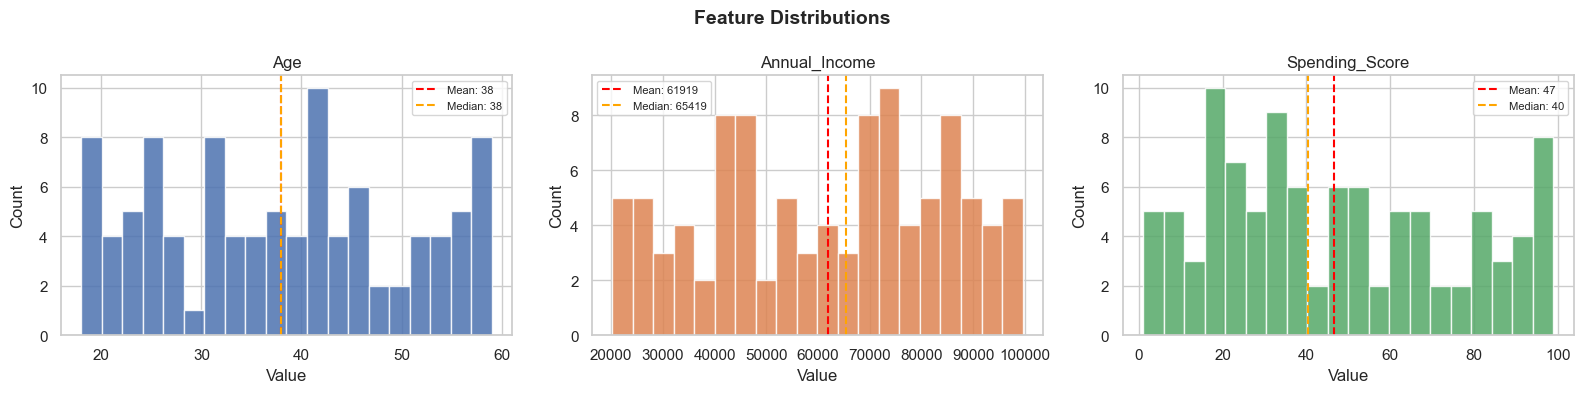

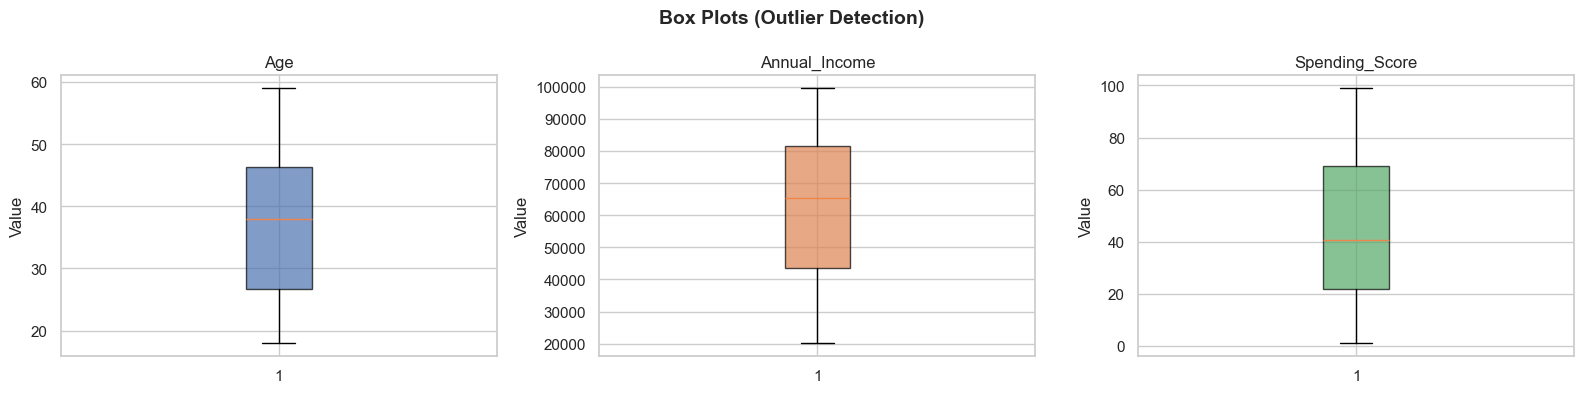

In [10]:
# --- Distribution plots for each feature ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, color in zip(axes, features, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.0f}')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Box plots for outlier visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Box Plots (Outlier Detection)', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, features, colors):
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=color, alpha=0.7))
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

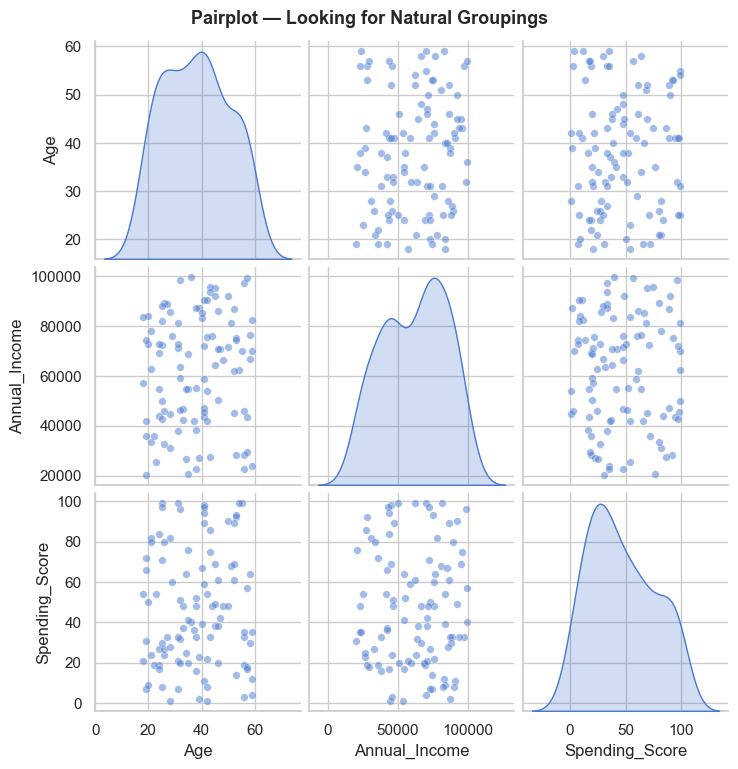

In [11]:
# --- Pairplot: visualize all feature combinations ---
# This is the most useful EDA - Exploratory Data Analysis chart for clustering — look for natural groups
sns.pairplot(
    df[features],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 30}
)
plt.suptitle('Pairplot — Looking for Natural Groupings', y=1.02, fontsize=13, fontweight='bold')
plt.show()

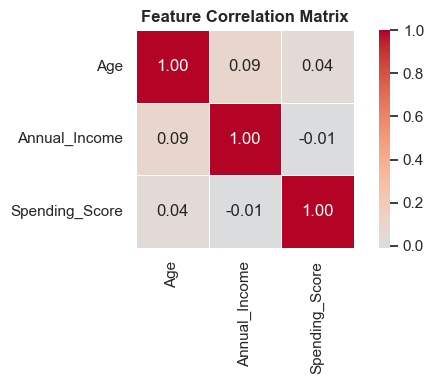

Interpretation: Values near ±1 mean strong correlation. Near 0 means independent features.


In [12]:
# --- Correlation heatmap ---
plt.figure(figsize=(6, 4))
corr = df[features].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print('Interpretation: Values near ±1 mean strong correlation. Near 0 means independent features.')

---
## 3. Data Preprocessing — Feature Scaling

### Why Scaling is Critical for Clustering

KMeans uses **Euclidean distance** to measure how close points are to cluster centers. If one feature has values in the range 0–100 and another in 10,000–150,000, the large-scale feature will dominate the distance calculation — the algorithm will barely "see" the small-scale feature.

**Example without scaling:**
```
Distance(Customer A, Customer B) ≈ √( (98000-30000)² + (90-10)² )
                                  ≈ √( 4,624,000,000 + 6,400 )
                                  ≈ 68,002  ← Annual_Income dominates completely
```

**After StandardScaler** (mean=0, std=1 for each feature), all features contribute equally.

> **Java analogy:** It's like normalizing units before comparing — you can't compare meters with kilometers without converting first.

In [13]:
# We use Annual_Income and Spending_Score for 2D clustering
# (easier to visualize; Age can be added for multi-dimensional clustering later)
X = df[['Annual_Income', 'Spending_Score']].copy()

# StandardScaler: transforms each feature to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=['Annual_Income_scaled', 'Spending_Score_scaled'])

print('Before scaling:')
print(X.describe())
print()
print('After scaling (mean≈0, std≈1):')
print(X_scaled_df.describe())

Before scaling:
       Annual_Income  Spending_Score
count         100.00          100.00
mean        61919.09           46.71
std         22596.27           29.17
min         20206.00            1.00
25%         43602.75           21.75
50%         65419.00           40.50
75%         81530.50           69.00
max         99575.00           99.00

After scaling (mean≈0, std≈1):
       Annual_Income_scaled  Spending_Score_scaled
count                100.00                 100.00
mean                   0.00                  -0.00
std                    1.01                   1.01
min                   -1.86                  -1.57
25%                   -0.81                  -0.86
50%                    0.16                  -0.21
75%                    0.87                   0.77
max                    1.67                   1.80


---
## 4. Finding the Optimal Number of Clusters

KMeans requires you to specify `k` (number of clusters) **upfront** — it cannot discover this on its own. Two standard methods help choose `k`:

### 4a. The Elbow Method (Inertia / WCSS)
**Inertia** = sum of squared distances from each point to its cluster centroid (also called Within-Cluster Sum of Squares, WCSS).

- More clusters → lower inertia (always)
- The "elbow" is where adding more clusters gives diminishing returns
- Look for the **bend** in the curve — that's your optimal `k`

### 4b. Silhouette Score
For each point, the silhouette score measures:
- `a` = average distance to other points **in its cluster** (cohesion)
- `b` = average distance to points in the **nearest other cluster** (separation)
- Score = `(b - a) / max(a, b)`

Range: **-1 to +1**
- `+1` → point is well inside its cluster, far from others ✅
- `0` → point is on the boundary between clusters
- `-1` → point was likely assigned to the wrong cluster ❌

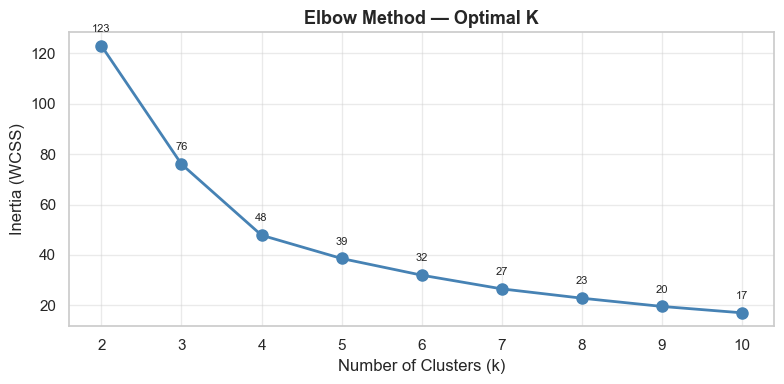

Look for the "elbow" — the k where the curve bends and flattens out.


In [14]:
# --- Elbow Method ---
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True, alpha=0.4)

# Annotate the elbow point (typically visible)
for x, y in zip(K_range, inertias):
    plt.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print('Look for the "elbow" — the k where the curve bends and flattens out.')

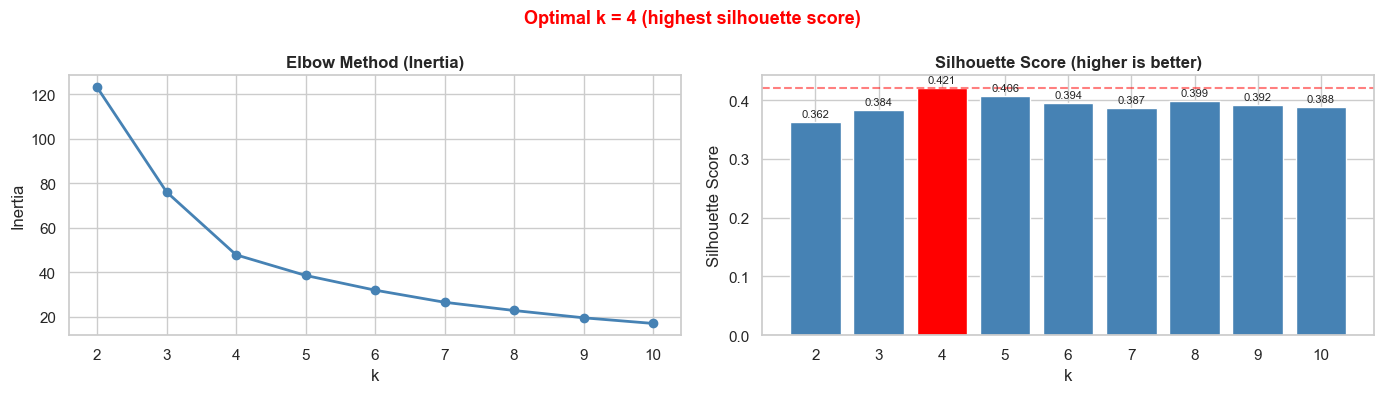


Best k by Silhouette Score: 4 (score = 0.4208)

  k=2: silhouette=0.3620
  k=3: silhouette=0.3836
  k=4: silhouette=0.4208 <-- BEST
  k=5: silhouette=0.4063
  k=6: silhouette=0.3944
  k=7: silhouette=0.3872
  k=8: silhouette=0.3987
  k=9: silhouette=0.3921
  k=10: silhouette=0.3883


In [15]:
# --- Silhouette Score Method ---
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

best_k = K_range[np.argmax(silhouette_scores)]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow on left
axes[0].plot(K_range, inertias, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(K_range)

# Silhouette on right
bar_colors = ['red' if k == best_k else 'steelblue' for k in K_range]
axes[1].bar(K_range, silhouette_scores, color=bar_colors, edgecolor='white')
axes[1].set_title('Silhouette Score (higher is better)', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(K_range)
axes[1].axhline(y=max(silhouette_scores), color='red', linestyle='--', alpha=0.5)

for k, s in zip(K_range, silhouette_scores):
    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Optimal k = {best_k} (highest silhouette score)', fontsize=13, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

print(f'\nBest k by Silhouette Score: {best_k} (score = {max(silhouette_scores):.4f})')
print()
for k, s in zip(K_range, silhouette_scores):
    marker = ' <-- BEST' if k == best_k else ''
    print(f'  k={k}: silhouette={s:.4f}{marker}')

---
## 5. KMeans Clustering — How the Algorithm Works

### Lloyd's Algorithm (KMeans internals)

```
1. Randomly place k centroids in the feature space
2. REPEAT:
   a. Assign each point to the nearest centroid  (E-step)
   b. Move each centroid to the mean of its assigned points  (M-step)
3. UNTIL centroids no longer move (convergence)
```

> **Java analogy:** Like a while loop where you keep rebalancing k buckets until each bucket's center of gravity stops moving.

### KMeans Limitations
- Requires specifying `k` upfront
- Sensitive to initial centroid placement (`n_init=10` runs it 10 times, picks best)
- Assumes spherical, similarly-sized clusters
- Sensitive to outliers (they pull centroids)
- Only works with numerical features

In [16]:
# --- Train final KMeans with optimal k ---
OPTIMAL_K = best_k

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10,          # Run 10 times with different seeds, pick best
    max_iter=300        # Max iterations per run
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Model converged in {kmeans.n_iter_} iterations')
print(f'Final inertia: {kmeans.inertia_:.2f}')
print()
print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print()
print(df.head(10))

Model converged in 10 iterations
Final inertia: 47.85

Cluster distribution:
Cluster
0    21
1    34
2    28
3    17
Name: count, dtype: int64

   CustomerID  Age  Annual_Income  Spending_Score  Cluster
0           1   56          28392              19        2
1           2   46          50535              20        2
2           3   32          98603              96        0
3           4   25          72256              71        0
4           5   38          55222              52        2
5           6   56          97373              33        1
6           7   36          99575              40        1
7           8   40          83335              39        1
8           9   28          30965              82        3
9          10   28          44538               1        2


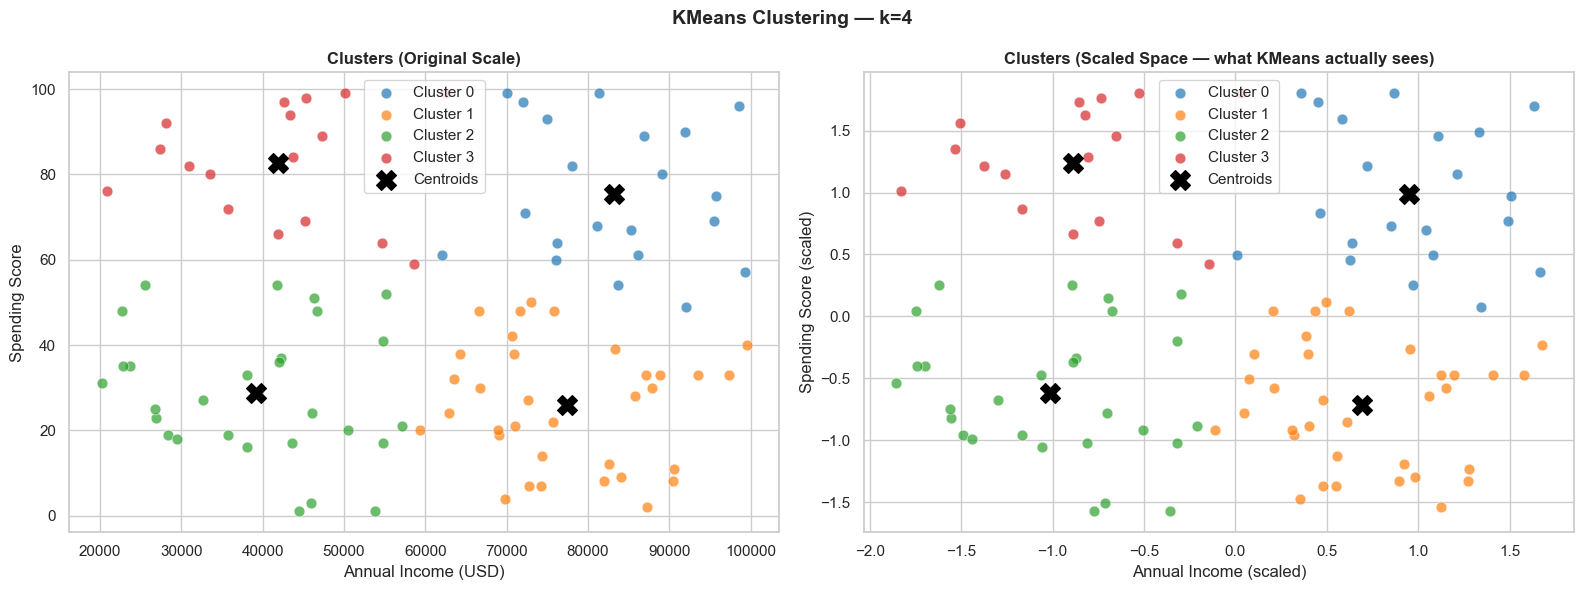

In [17]:
# --- Visualize clusters with centroids ---
palette = sns.color_palette('tab10', OPTIMAL_K)
cluster_colors = [palette[c] for c in df['Cluster']]

# Get centroids in original scale (inverse transform)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot in original scale ---
for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster_id
    axes[0].scatter(
        df.loc[mask, 'Annual_Income'],
        df.loc[mask, 'Spending_Score'],
        c=[palette[cluster_id]],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidth=0.5
    )

axes[0].scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)
axes[0].set_title('Clusters (Original Scale)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Annual Income (USD)')
axes[0].set_ylabel('Spending Score')
axes[0].legend()

# --- Plot in scaled space ---
for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster_id
    axes[1].scatter(
        X_scaled[mask, 0],
        X_scaled[mask, 1],
        c=[palette[cluster_id]],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidth=0.5
    )

axes[1].scatter(
    centroids_scaled[:, 0],
    centroids_scaled[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)
axes[1].set_title('Clusters (Scaled Space — what KMeans actually sees)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Annual Income (scaled)')
axes[1].set_ylabel('Spending Score (scaled)')
axes[1].legend()

plt.suptitle(f'KMeans Clustering — k={OPTIMAL_K}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Cluster Profiling & Business Insights

Clustering is only useful if you can **interpret** what each cluster means in business terms. This step turns numbers into actionable segments.

In [18]:
# --- Cluster statistics ---
cluster_profile = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].agg(
    ['mean', 'median', 'std', 'count']
)

print('=== Cluster Profile (aggregated stats) ===')
print(cluster_profile.to_string())

print('\n=== Cluster Sizes ===')
sizes = df['Cluster'].value_counts().sort_index()
for cluster_id, count in sizes.items():
    pct = count / len(df) * 100
    print(f'  Cluster {cluster_id}: {count} customers ({pct:.1f}%)')

=== Cluster Profile (aggregated stats) ===
          Age                    Annual_Income                         Spending_Score                   
         mean median   std count          mean   median      std count           mean median   std count
Cluster                                                                                                 
0       41.43  45.00 12.45    21      83269.52 83734.00 10209.94    21          75.29  71.00 16.18    21
1       37.65  38.50 12.07    34      77479.88 74326.00 10593.49    34          25.82  27.50 14.20    34
2       37.32  36.00 12.48    28      39170.89 41905.00 11515.25    28          28.79  26.00 15.61    28
3       35.06  35.00 11.89    17      41891.06 43419.00 11363.96    17          82.71  84.00 13.19    17

=== Cluster Sizes ===
  Cluster 0: 21 customers (21.0%)
  Cluster 1: 34 customers (34.0%)
  Cluster 2: 28 customers (28.0%)
  Cluster 3: 17 customers (17.0%)


In [19]:
# --- Business labels: assign meaningful names to each cluster ---
# (based on mean income vs mean spending)
cluster_means = df.groupby('Cluster')[['Annual_Income', 'Spending_Score']].mean()

income_median = cluster_means['Annual_Income'].median()
spending_median = cluster_means['Spending_Score'].median()

def label_cluster(row):
    high_income  = row['Annual_Income']  >= income_median
    high_spending = row['Spending_Score'] >= spending_median
    if high_income and high_spending:
        return 'High Value (Premium)'
    elif high_income and not high_spending:
        return 'High Income, Low Spend (Savers)'
    elif not high_income and high_spending:
        return 'Low Income, High Spend (Impulsive)'
    else:
        return 'Low Income, Low Spend (Budget)'

cluster_labels = cluster_means.apply(label_cluster, axis=1)
print('=== Cluster Business Labels ===')
for cluster_id, label in cluster_labels.items():
    n = sizes[cluster_id]
    income = cluster_means.loc[cluster_id, 'Annual_Income']
    spending = cluster_means.loc[cluster_id, 'Spending_Score']
    print(f'  Cluster {cluster_id} → "{label}"')
    print(f'    Mean Income: ${income:,.0f} | Mean Spending Score: {spending:.1f} | Size: {n}')
    print()

=== Cluster Business Labels ===
  Cluster 0 → "High Value (Premium)"
    Mean Income: $83,270 | Mean Spending Score: 75.3 | Size: 21

  Cluster 1 → "High Income, Low Spend (Savers)"
    Mean Income: $77,480 | Mean Spending Score: 25.8 | Size: 34

  Cluster 2 → "Low Income, Low Spend (Budget)"
    Mean Income: $39,171 | Mean Spending Score: 28.8 | Size: 28

  Cluster 3 → "Low Income, High Spend (Impulsive)"
    Mean Income: $41,891 | Mean Spending Score: 82.7 | Size: 17



In [ ]:
# --- Visualize cluster profiles with grouped bar chart ---
# Normalize to 0-1 range for fair comparison across different scales
profile_means = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean()
profile_norm = (profile_means - profile_means.min()) / (profile_means.max() - profile_means.min())

x = np.arange(len(profile_norm.columns))
width = 0.8 / OPTIMAL_K

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — normalized
for i, cluster_id in enumerate(profile_norm.index):
    offset = (i - OPTIMAL_K / 2 + 0.5) * width
    label = cluster_labels.get(cluster_id, f'Cluster {cluster_id}')
    axes[0].bar(x + offset, profile_norm.loc[cluster_id], width, label=f'C{cluster_id}: {label}',
                color=palette[cluster_id], edgecolor='white', alpha=0.85)

axes[0].set_title('Cluster Profiles (Normalized)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Age', 'Annual Income', 'Spending Score'])
axes[0].set_ylabel('Normalized Value (0-1)')
axes[0].legend(loc='upper right', fontsize=8)

# Scatter: Income vs Spending, sized by Age
sc = axes[1].scatter(
    df['Annual_Income'],
    df['Spending_Score'],
    c=df['Cluster'],
    cmap='tab10',
    s=df['Age'],           # point size = age (bigger circle = older)
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)
axes[1].set_title('Income vs Spending (point size = Age)', fontweight='bold')
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Spending Score')
plt.colorbar(sc, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

---
## 7. Alternative Clustering Algorithms

KMeans isn't the only option. Different algorithms handle different data shapes and requirements.

| Algorithm | Type | Needs k? | Handles Noise? | Handles Non-spherical? |
|-----------|------|----------|---------------|------------------------|
| KMeans | Centroid-based | Yes | No | No |
| Hierarchical | Linkage-based | No (post-hoc) | No | Partially |
| DBSCAN | Density-based | No | **Yes** | **Yes** |

### 7a. Hierarchical Clustering

Builds a **tree of clusters (dendrogram)** by progressively merging the closest clusters bottom-up (agglomerative) or splitting top-down (divisive).

- **No need to specify k upfront** — you cut the tree at any level
- **Dendrogram** lets you visually choose the cut point
- More computationally expensive: O(n² log n) vs KMeans O(nki)

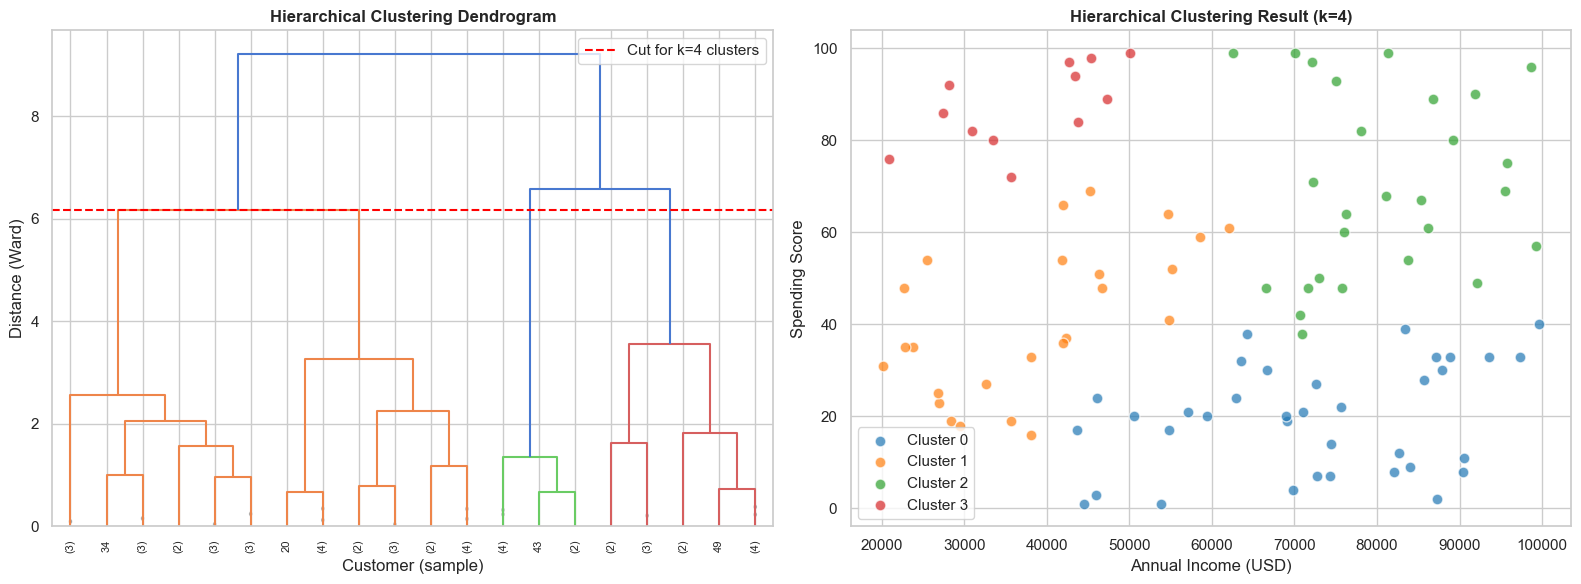

Adjusted Rand Index (KMeans vs Hierarchical): 0.5416
ARI = 1.0 means identical clustering; 0.0 means random agreement


In [20]:
# --- Hierarchical Clustering ---

# Compute linkage matrix (Ward method minimizes within-cluster variance)
# Use a sample for dendrogram readability if data is large
sample_size = min(50, len(X_scaled))
X_sample = X_scaled[:sample_size]

linkage_matrix = linkage(X_sample, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Dendrogram ---
dendrogram(
    linkage_matrix,
    ax=axes[0],
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True
)
axes[0].set_title('Hierarchical Clustering Dendrogram', fontweight='bold')
axes[0].set_xlabel('Customer (sample)')
axes[0].set_ylabel('Distance (Ward)')

# Draw cut line at the level corresponding to OPTIMAL_K clusters
# The longest vertical line that doesn't cross a horizontal line is a good cut point
cut_height = linkage_matrix[-(OPTIMAL_K - 1), 2]
axes[0].axhline(y=cut_height, color='red', linestyle='--', linewidth=1.5,
                label=f'Cut for k={OPTIMAL_K} clusters')
axes[0].legend()

# --- Cluster scatter using AgglomerativeClustering on full data ---
agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)

for cluster_id in range(OPTIMAL_K):
    mask = agg_labels == cluster_id
    axes[1].scatter(
        df.loc[mask, 'Annual_Income'],
        df.loc[mask, 'Spending_Score'],
        c=[palette[cluster_id]],
        label=f'Cluster {cluster_id}',
        alpha=0.7, s=60, edgecolors='white'
    )

axes[1].set_title(f'Hierarchical Clustering Result (k={OPTIMAL_K})', fontweight='bold')
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Spending Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# Compare agreement with KMeans
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['Cluster'], agg_labels)
print(f'Adjusted Rand Index (KMeans vs Hierarchical): {ari:.4f}')
print('ARI = 1.0 means identical clustering; 0.0 means random agreement')

### 7b. DBSCAN — Density-Based Spatial Clustering

DBSCAN doesn't assume clusters are spherical. It defines clusters as **dense regions** separated by sparse regions.

**Key parameters:**
- `eps` (ε) — the radius of the neighborhood around each point
- `min_samples` — minimum points required to form a dense region (core point)

**Point types:**
- **Core point** — has ≥ `min_samples` neighbors within ε
- **Border point** — within ε of a core point but not itself a core point
- **Noise point** — neither core nor border → labeled `-1` (outlier)

> **Advantage over KMeans:** Automatically detects outliers and discovers arbitrarily-shaped clusters.

DBSCAN — eps=0.4, min_samples=5
  Clusters found: 3
  Noise points: 38 (38.0%)


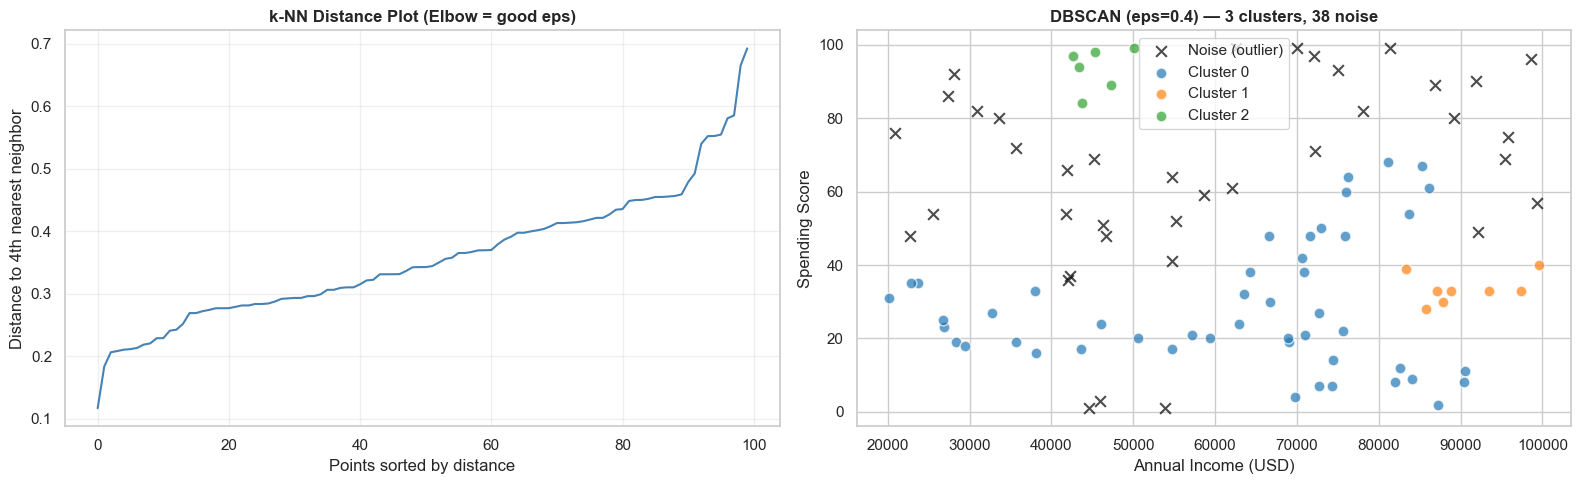


Tip: Try different eps values using the KNN distance plot elbow as a guide.


In [21]:
# --- DBSCAN ---
# Choosing eps: use k-nearest-neighbor distance plot
from sklearn.neighbors import NearestNeighbors

# Find the distance to the 4th nearest neighbor for each point
k_neighbors = 4
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
knn_distances = np.sort(distances[:, k_neighbors - 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KNN distance plot to choose eps
axes[0].plot(knn_distances, linewidth=1.5, color='steelblue')
axes[0].set_title('k-NN Distance Plot (Elbow = good eps)', fontweight='bold')
axes[0].set_xlabel('Points sorted by distance')
axes[0].set_ylabel(f'Distance to {k_neighbors}th nearest neighbor')
axes[0].grid(True, alpha=0.3)

# Run DBSCAN
eps_value = 0.4
dbscan = DBSCAN(eps=eps_value, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'DBSCAN — eps={eps_value}, min_samples=5')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)')

# Plot DBSCAN result
unique_labels = sorted(set(dbscan_labels))
db_palette = sns.color_palette('tab10', max(n_clusters_db, 1))

for lbl in unique_labels:
    mask = dbscan_labels == lbl
    if lbl == -1:
        axes[1].scatter(df.loc[mask, 'Annual_Income'], df.loc[mask, 'Spending_Score'],
                        c='black', marker='x', s=60, label='Noise (outlier)', alpha=0.7)
    else:
        axes[1].scatter(df.loc[mask, 'Annual_Income'], df.loc[mask, 'Spending_Score'],
                        c=[db_palette[lbl]], s=60, label=f'Cluster {lbl}',
                        alpha=0.7, edgecolors='white')

axes[1].set_title(f'DBSCAN (eps={eps_value}) — {n_clusters_db} clusters, {n_noise} noise', fontweight='bold')
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Spending Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nTip: Try different eps values using the KNN distance plot elbow as a guide.')

---
## 8. Dimensionality Reduction with PCA

So far we clustered on 2 features (`Annual_Income`, `Spending_Score`). In real-world problems, you might have 50+ features. PCA helps:

1. **Compress** many features into 2-3 components for visualization
2. **Remove noise** — keep only the directions of maximum variance
3. **Speed up** clustering on high-dimensional data

### How PCA Works
PCA finds the directions (principal components) that capture the most variance in the data:
- **PC1** = the direction of maximum variance
- **PC2** = the direction of second most variance, perpendicular to PC1
- ... and so on

Each component is a linear combination of the original features.

> **Java analogy:** Like creating a View object that projects a complex entity onto its most important attributes.

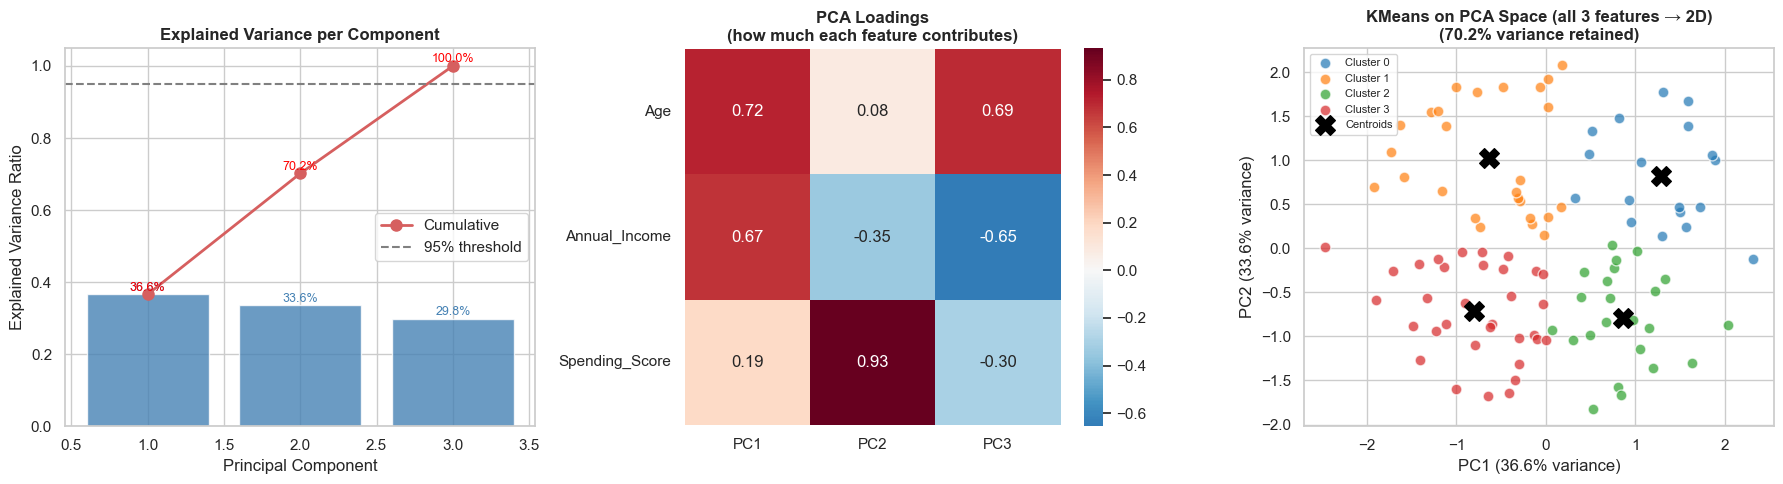

PCA Loadings interpretation:
                PC1   PC2   PC3
Age            0.72  0.08  0.69
Annual_Income  0.67 -0.35 -0.65
Spending_Score 0.19  0.93 -0.30

Positive loading = feature moves in same direction as PC
Negative loading = feature moves in opposite direction


In [22]:
# --- PCA on all 3 features (Age, Income, Spending) ---
X_all = df[['Age', 'Annual_Income', 'Spending_Score']].copy()
X_all_scaled = StandardScaler().fit_transform(X_all)

# Fit PCA to retain all components first (to inspect explained variance)
pca_full = PCA(n_components=3)
pca_full.fit(X_all_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
axes[0].bar(range(1, 4), explained_var, alpha=0.8, color='steelblue', edgecolor='white')
axes[0].plot(range(1, 4), cumulative_var, 'ro-', linewidth=2, markersize=8, label='Cumulative')
axes[0].axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    axes[0].text(i+1, ev + 0.01, f'{ev:.1%}', ha='center', fontsize=9, color='steelblue')
    axes[0].text(i+1, cv + 0.01, f'{cv:.1%}', ha='center', fontsize=9, color='red')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].legend()

# PCA loadings (how much each original feature contributes to each PC)
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=['Age', 'Annual_Income', 'Spending_Score'],
    columns=['PC1', 'PC2', 'PC3']
)

sns.heatmap(
    loadings,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, ax=axes[1]
)
axes[1].set_title('PCA Loadings\n(how much each feature contributes)', fontweight='bold')

# Project to 2D and visualize clusters
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_all_scaled)

# Re-cluster in PCA space
km_pca = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
pca_labels = km_pca.fit_predict(X_pca)

for cluster_id in range(OPTIMAL_K):
    mask = pca_labels == cluster_id
    axes[2].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[palette[cluster_id]], label=f'Cluster {cluster_id}',
        alpha=0.7, s=60, edgecolors='white'
    )

axes[2].scatter(
    km_pca.cluster_centers_[:, 0], km_pca.cluster_centers_[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)
axes[2].set_title(f'KMeans on PCA Space (all 3 features → 2D)\n({cumulative_var[1]:.1%} variance retained)', fontweight='bold')
axes[2].set_xlabel(f'PC1 ({explained_var[0]:.1%} variance)')
axes[2].set_ylabel(f'PC2 ({explained_var[1]:.1%} variance)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('PCA Loadings interpretation:')
print(loadings.to_string())
print('\nPositive loading = feature moves in same direction as PC')
print('Negative loading = feature moves in opposite direction')

---
## 9. Model Evaluation Metrics

Since we have no ground truth labels, **internal validation metrics** measure cluster quality:

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| **Silhouette Score** | Cohesion vs separation | Closer to +1 |
| **Davies-Bouldin Index** | Avg similarity between each cluster and its most similar cluster | Closer to 0 |
| **Calinski-Harabasz Score** | Ratio of between-cluster to within-cluster dispersion | Higher |
| **Inertia (WCSS)** | Total within-cluster sum of squares | Lower (relative) |

=== Cluster Evaluation Metrics ===
  Silhouette Score:       0.4208  (range: -1 to +1, higher is better)
  Davies-Bouldin Index:   0.7442  (lower is better)
  Calinski-Harabasz:      101.76  (higher is better)
  Inertia (WCSS):         47.85  (lower is better, relative)


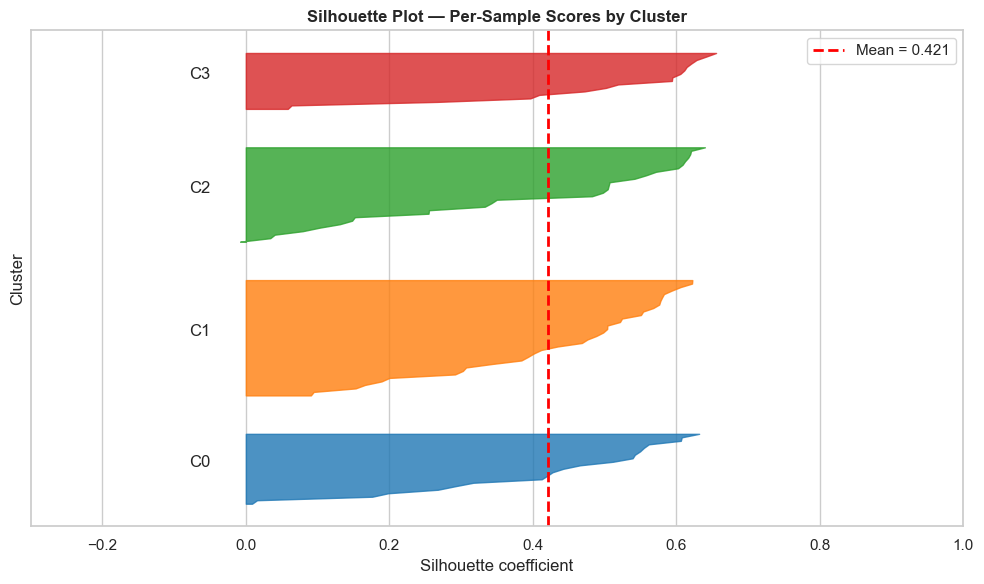


Interpretation:
  Wide bars = large, consistent cluster
  Points below 0 = potentially misassigned
  All bars should ideally be above the mean (red line)


In [23]:
# --- Compute all evaluation metrics for our KMeans model ---
labels = df['Cluster'].values

sil_score  = silhouette_score(X_scaled, labels)
db_score   = davies_bouldin_score(X_scaled, labels)
ch_score   = calinski_harabasz_score(X_scaled, labels)
inertia    = kmeans.inertia_

print('=== Cluster Evaluation Metrics ===')
print(f'  Silhouette Score:       {sil_score:.4f}  (range: -1 to +1, higher is better)')
print(f'  Davies-Bouldin Index:   {db_score:.4f}  (lower is better)')
print(f'  Calinski-Harabasz:      {ch_score:.2f}  (higher is better)')
print(f'  Inertia (WCSS):         {inertia:.2f}  (lower is better, relative)')

# --- Silhouette plot: visualize per-cluster and per-sample scores ---
fig, ax = plt.subplots(figsize=(10, 6))

sample_silhouette_values = silhouette_samples(X_scaled, labels)
y_lower = 10

for cluster_id in range(OPTIMAL_K):
    cluster_sil = sample_silhouette_values[labels == cluster_id]
    cluster_sil.sort()
    size = cluster_sil.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil,
        facecolor=palette[cluster_id],
        edgecolor=palette[cluster_id],
        alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size, f'C{cluster_id}', ha='right')
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='red', linestyle='--', linewidth=2, label=f'Mean = {sil_score:.3f}')
ax.set_title('Silhouette Plot — Per-Sample Scores by Cluster', fontweight='bold', fontsize=12)
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend()
ax.set_xlim([-0.3, 1.0])

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  Wide bars = large, consistent cluster')
print('  Points below 0 = potentially misassigned')
print('  All bars should ideally be above the mean (red line)')

---
## 10. Production-Ready Model Pipeline

### Why a Pipeline?

In production, the **same preprocessing** used during training must be applied to new data at inference time. Without a pipeline, it's easy to forget to scale new input.

> **Java analogy:** Like encapsulating `preprocessData()` + `predict()` into a single service method — callers shouldn't need to know the internals.

### Production Concerns Covered Here
- `sklearn.Pipeline` wraps scaling + model into one reusable object
- `joblib.dump` / `joblib.load` — model persistence to disk
- Input validation before prediction
- Batch prediction on new customers

In [24]:
# --- Build the production pipeline ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10))
])

# Fit on the original (unscaled) feature data
X_production = df[['Annual_Income', 'Spending_Score']]
pipeline.fit(X_production)

print('Pipeline steps:')
for name, step in pipeline.steps:
    print(f'  {name}: {step}')

# Verify it produces the same clusters
pipeline_labels = pipeline.predict(X_production)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['Cluster'], pipeline_labels)
print(f'\nPipeline vs standalone model agreement (ARI): {ari:.4f}')
print('(1.0 = identical, any minor difference is due to cluster label ordering)')

Pipeline steps:
  scaler: StandardScaler()
  kmeans: KMeans(n_clusters=4, n_init=10, random_state=42)

Pipeline vs standalone model agreement (ARI): 1.0000
(1.0 = identical, any minor difference is due to cluster label ordering)


In [25]:
# --- Save model to disk ---
MODEL_PATH = 'customer_segmentation_model.joblib'

joblib.dump(pipeline, MODEL_PATH)
model_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'Model saved to: {MODEL_PATH}  ({model_size_kb:.1f} KB)')

# --- Load model back (simulates a separate inference service) ---
loaded_pipeline = joblib.load(MODEL_PATH)
print(f'Model loaded successfully: {type(loaded_pipeline).__name__}')

Model saved to: customer_segmentation_model.joblib  (1.9 KB)
Model loaded successfully: Pipeline


In [26]:
# --- Input validation helper ---
def validate_customer_input(data: pd.DataFrame) -> None:
    """Validate input before prediction. Raises ValueError on bad input."""
    required_cols = ['Annual_Income', 'Spending_Score']
    missing_cols = [c for c in required_cols if c not in data.columns]
    if missing_cols:
        raise ValueError(f'Missing required columns: {missing_cols}')
    if data.isnull().any().any():
        raise ValueError('Input contains null values. Impute or drop before prediction.')
    if (data['Annual_Income'] < 0).any():
        raise ValueError('Annual_Income cannot be negative.')
    if not data['Spending_Score'].between(1, 100).all():
        raise ValueError('Spending_Score must be between 1 and 100.')


def predict_segment(new_customers: pd.DataFrame, model_path: str = MODEL_PATH) -> pd.DataFrame:
    """
    Load the saved pipeline and predict customer segments.

    Args:
        new_customers: DataFrame with columns [Annual_Income, Spending_Score]
        model_path: Path to the saved joblib model file

    Returns:
        DataFrame with original data + Cluster column + segment label
    """
    validate_customer_input(new_customers)
    model = joblib.load(model_path)
    clusters = model.predict(new_customers[['Annual_Income', 'Spending_Score']])
    result = new_customers.copy()
    result['Cluster'] = clusters
    result['Segment'] = result['Cluster'].map(cluster_labels)
    return result


# --- Test with new customers ---
new_customers = pd.DataFrame({
    'Annual_Income':   [120000, 25000,  80000, 45000, 95000],
    'Spending_Score':  [   88,     72,     30,    55,    45]
})

print('New customer data:')
print(new_customers)
print()

predictions = predict_segment(new_customers)
print('Predictions:')
print(predictions.to_string(index=False))

New customer data:
   Annual_Income  Spending_Score
0         120000              88
1          25000              72
2          80000              30
3          45000              55
4          95000              45

Predictions:
 Annual_Income  Spending_Score  Cluster                            Segment
        120000              88        0               High Value (Premium)
         25000              72        3 Low Income, High Spend (Impulsive)
         80000              30        1    High Income, Low Spend (Savers)
         45000              55        2     Low Income, Low Spend (Budget)
         95000              45        1    High Income, Low Spend (Savers)


In [ ]:
# --- Visualize new predictions alongside training data ---
fig, ax = plt.subplots(figsize=(10, 7))

# Training data (faded)
for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'Annual_Income'],
        df.loc[mask, 'Spending_Score'],
        c=[palette[cluster_id]], alpha=0.3, s=40, edgecolors='none'
    )

# New predictions (bright, large markers)
for _, row in predictions.iterrows():
    ax.scatter(
        row['Annual_Income'], row['Spending_Score'],
        c=[palette[row['Cluster']]], s=250, marker='*',
        edgecolors='black', linewidth=1.5, zorder=10
    )
    ax.annotate(
        f"  C{row['Cluster']}",
        (row['Annual_Income'], row['Spending_Score']),
        fontsize=9, fontweight='bold'
    )

# Add centroids
ax.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)

ax.set_title('Predicting New Customers → Cluster Assignment\n(stars = new customers, faded = training data)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Annual Income (USD)')
ax.set_ylabel('Spending Score')

# Legend
for cluster_id in range(OPTIMAL_K):
    label = cluster_labels.get(cluster_id, f'Cluster {cluster_id}')
    ax.scatter([], [], c=[palette[cluster_id]], label=f'C{cluster_id}: {label}', s=60)

ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## Summary

### What You Learned

| Step | Key Concept | Why It Matters |
|------|------------|---------------|
| EDA | Know your data | Catch issues before modeling |
| Feature Scaling | StandardScaler | Distance-based algorithms need equal-weight features |
| Elbow + Silhouette | Optimal k | Never guess k — measure it |
| KMeans | Lloyd's algorithm | E-step + M-step until convergence |
| Cluster Profiling | Business interpretation | Clusters are useless without meaning |
| Hierarchical | Dendrogram | No k required; shows tree structure |
| DBSCAN | Density-based | Detects outliers; finds non-spherical clusters |
| PCA | Dimensionality reduction | Visualize high-dimensional clusters in 2D |
| Silhouette / DB / CH | Internal validation | Measure quality without ground truth |
| Pipeline + joblib | Production readiness | Reproducible inference; no preprocessing drift |

### Choosing the Right Algorithm

```
Do you know k upfront?  →  Yes: KMeans (fast, scalable)
                        →  No:  Hierarchical (if small data) or DBSCAN

Unusual cluster shapes?  →  DBSCAN
Outliers in data?        →  DBSCAN (labels them as noise)
Many features (>10)?     →  PCA first, then cluster
Need interpretability?   →  Hierarchical (dendrogram is intuitive)
```

### Next Steps
- Try clustering on all 3 features (`Age`, `Annual_Income`, `Spending_Score`)
- Try Gaussian Mixture Models (GMM) — soft cluster assignments with probability
- Try t-SNE for non-linear dimensionality reduction when PCA doesn't separate well
- Add categorical features using `OneHotEncoder` before scaling